In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [2]:
audio_path = "dataset/recordings/zero/0_george_0.wav"

In [3]:
audio, sr = librosa.load(audio_path, sr=None)

In [4]:
print("Sampling Rate:", sr)
print("Number of Samples:", len(audio))

Sampling Rate: 8000
Number of Samples: 2384


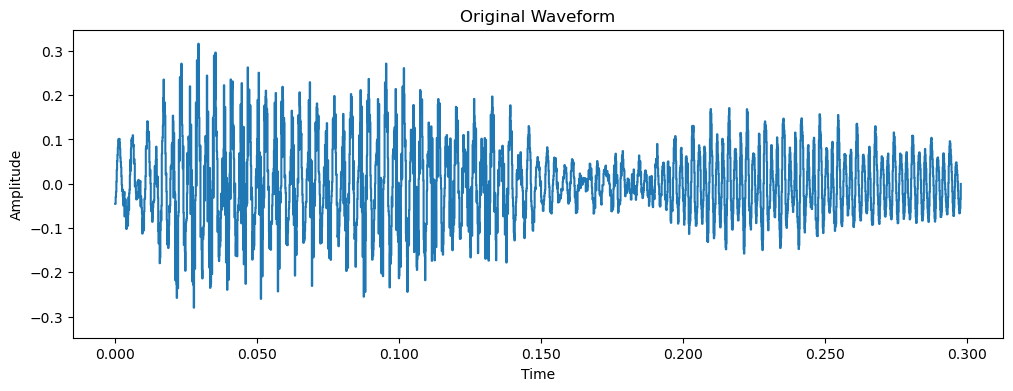

In [5]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Original Waveform")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

In [6]:
audio_resampled = librosa.resample(
    audio,
    orig_sr=sr,
    target_sr=16000
)

new_sr = 16000

In [7]:
audio_normalized = librosa.util.normalize(audio_resampled)

In [8]:
audio_trimmed, index = librosa.effects.trim(audio_normalized)

In [9]:
print("Original Length:", len(audio))

print("Processed Length:", len(audio_trimmed))

Original Length: 2384
Processed Length: 4768


In [10]:
print("Original Sampling Rate:", sr)
print("New Sampling Rate:", new_sr)

Original Sampling Rate: 8000
New Sampling Rate: 16000


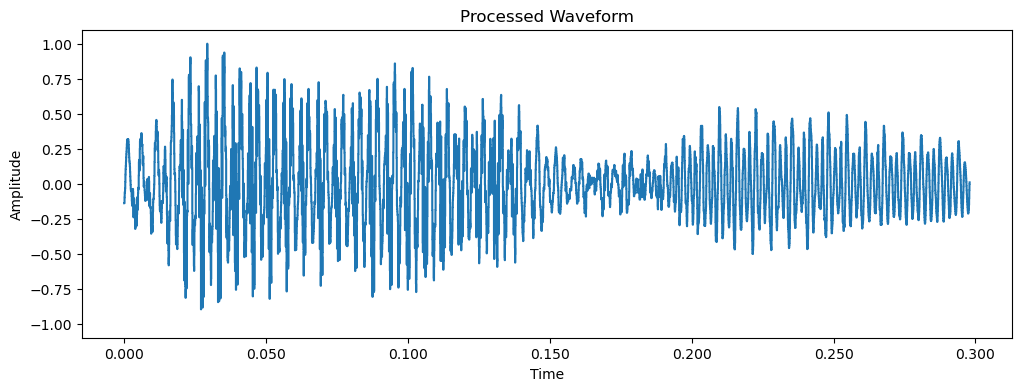

In [11]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(audio_trimmed, sr=new_sr)

plt.title("Processed Waveform")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

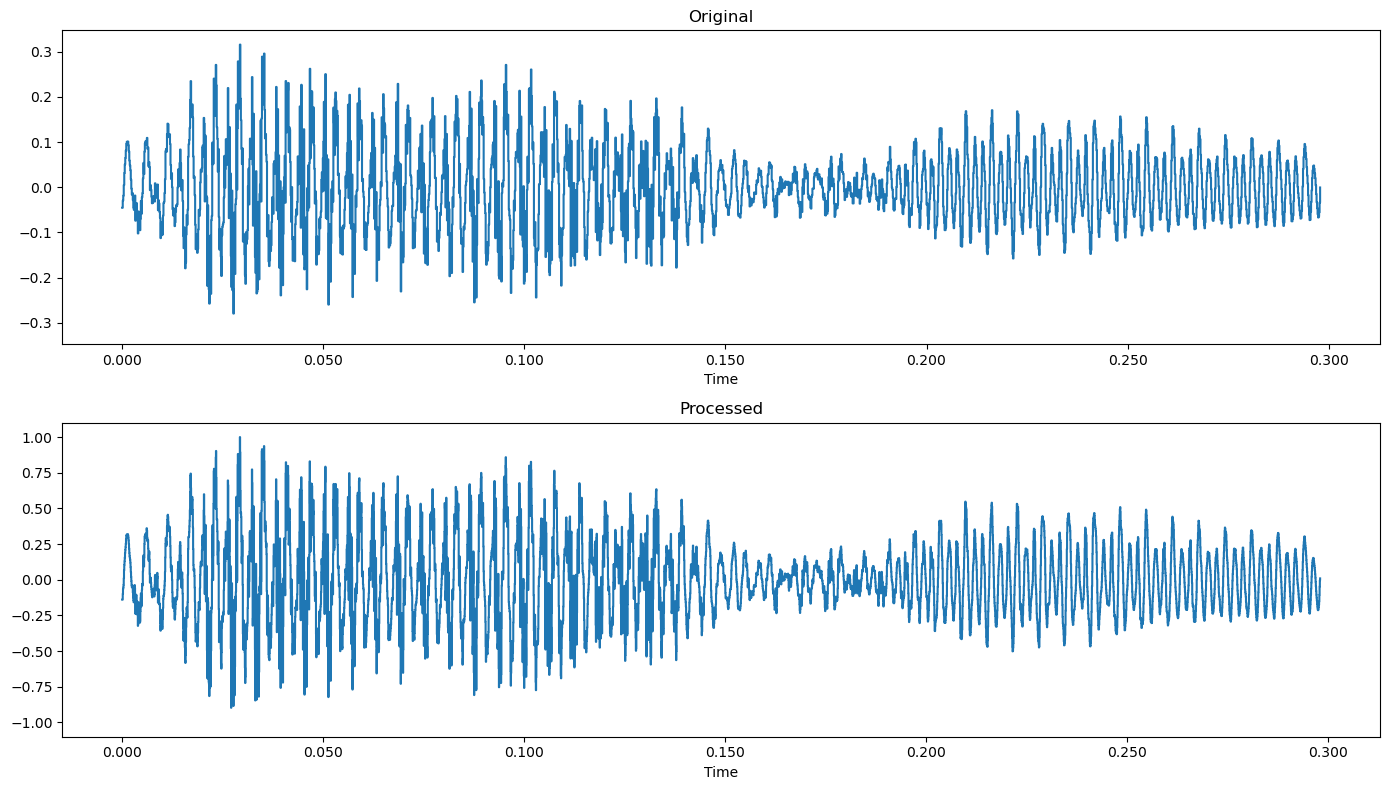

In [12]:
plt.figure(figsize=(14,8))

plt.subplot(2,1,1)

librosa.display.waveshow(audio, sr=sr)

plt.title("Original")

plt.subplot(2,1,2)

librosa.display.waveshow(audio_trimmed, sr=new_sr)

plt.title("Processed")

plt.tight_layout()

plt.show()

In [13]:
mel_original = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

mel_original_db = librosa.power_to_db(
    mel_original,
    ref=np.max
)

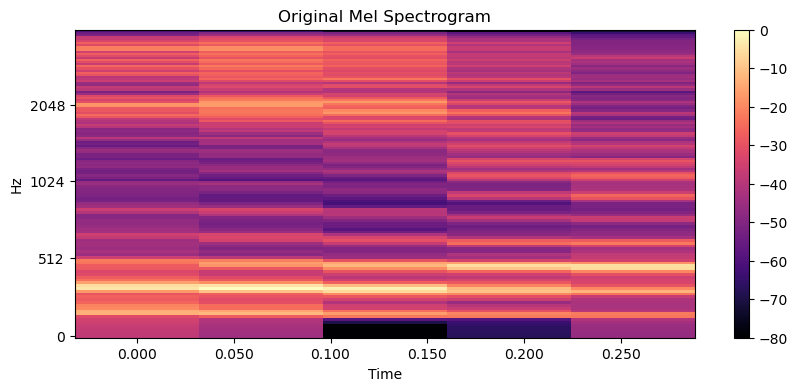

In [14]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_original_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()

plt.title("Original Mel Spectrogram")

plt.show()

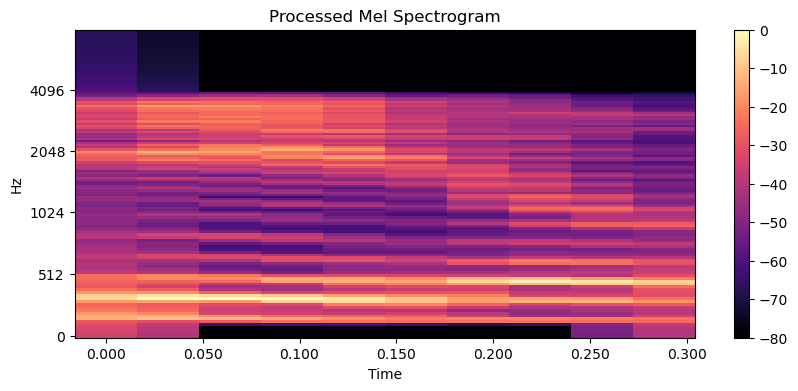

In [15]:
mel_processed = librosa.feature.melspectrogram(
    y=audio_trimmed,
    sr=new_sr
)

mel_processed_db = librosa.power_to_db(
    mel_processed,
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_processed_db,
    sr=new_sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()

plt.title("Processed Mel Spectrogram")

plt.show()

In [16]:
mfcc_original = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

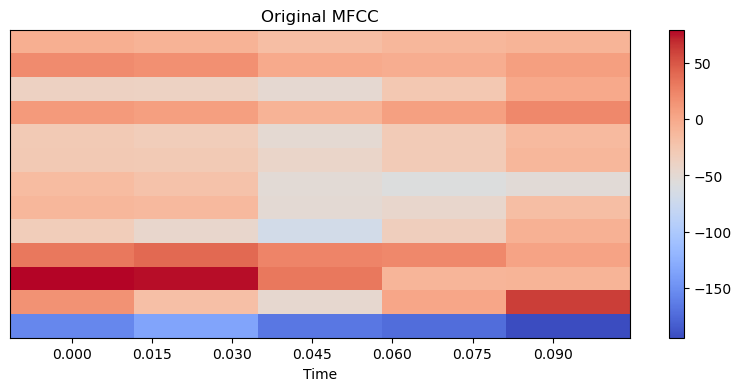

In [17]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc_original,
    x_axis='time'
)

plt.colorbar()

plt.title("Original MFCC")

plt.show()

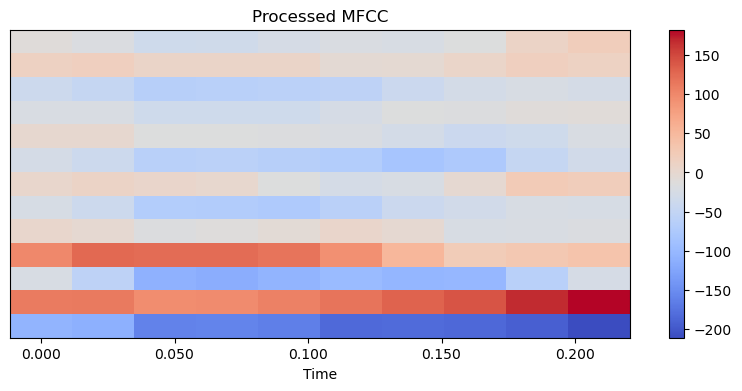

In [18]:
mfcc_processed = librosa.feature.mfcc(
    y=audio_trimmed,
    sr=new_sr,
    n_mfcc=13
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc_processed,
    x_axis='time'
)

plt.colorbar()

plt.title("Processed MFCC")

plt.show()

In [19]:
fft = np.fft.fft(audio_trimmed)

frequencies = np.fft.fftfreq(
    len(fft),
    1/new_sr
)

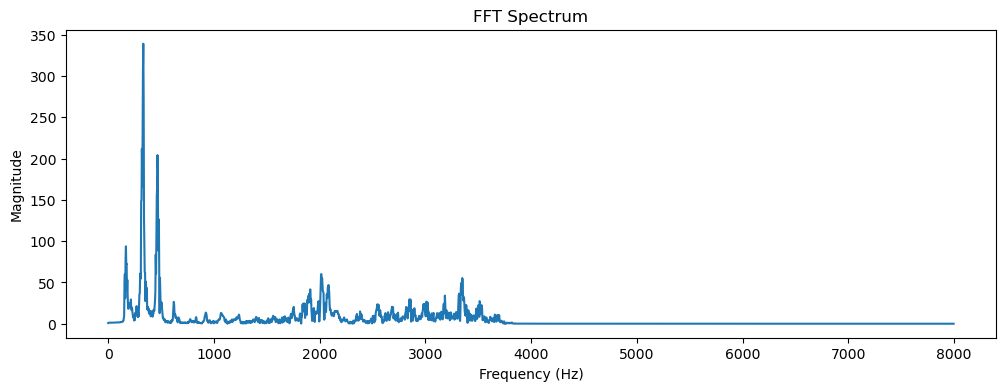

In [20]:
plt.figure(figsize=(12,4))

plt.plot(
    frequencies[:len(frequencies)//2],
    np.abs(fft[:len(fft)//2])
)

plt.title("FFT Spectrum")

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

plt.show()

Observation

The audio sample was successfully loaded and preprocessed. During preprocessing, the audio was resampled from 8000 Hz to 16000 Hz, normalized to maintain a consistent volume level, and trimmed to remove any silence from the beginning and end of the recording.
After preprocessing, the number of audio samples increased because the sampling rate was doubled. However, the actual duration of the audio remained almost the same. The selected audio clip contained very little silence, so the trimming step did not significantly reduce its length.
The waveform, Mel-spectrogram, MFCC heatmap, and FFT spectrum clearly show the characteristics of the audio signal before and after preprocessing. The processed audio is more suitable for further speech analysis and machine learning tasks because it has a standardized sampling rate and consistent amplitude.